In [1]:
# ============================================
# DAY 2: U-NET IMPLEMENTATION + TRAINING SETUP
# ============================================

# Step 1: Install + Upgrade libraries (run once)
!pip install torch torchvision matplotlib opencv-python numpy pandas pillow tqdm -q

# Step 2: Re-download dataset (in case kernel restarted)
!kaggle datasets download -d mateuszbuda/lgg-mri-segmentation -q
!unzip -qo lgg-mri-segmentation.zip -d lgg_mri_data
!rm lgg-mri-segmentation.zip

# Step 3: Import ALL libraries needed for today
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import random_split
from tqdm import tqdm  # Progress bar

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Using device: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

print("\n All libraries imported successfully!")

Dataset URL: https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation
License(s): CC-BY-NC-SA-4.0
 Using device: cuda
   GPU: Tesla T4
   Memory: 15.6 GB

 All libraries imported successfully!


In [2]:
# ============================================
# ENHANCED DATASET CLASS
# ============================================

class BrainTumorDataset(Dataset):
    """
    Brain Tumor Segmentation Dataset for LGG-MRI
    
    Features:
    - Loads grayscale MRI images
    - Loads binary tumor masks
    - Returns PyTorch tensors ready for training
    """
    
    def __init__(self, data_dir, target_size=(256, 256), augment=False):
        """
        Args:
            data_dir: Path to kaggle_3m folder
            target_size: (H, W) for resizing
            augment: Whether to apply augmentation (training only)
        """
        self.data_dir = Path(data_dir)
        self.target_size = target_size
        self.augment = augment
        self.image_files = []
        self.mask_files = []
        
        # Scan all patient folders
        patient_folders = sorted([f for f in self.data_dir.iterdir() if f.is_dir()])
        
        for patient_dir in patient_folders:
            # Get all .tif files that are NOT masks
            imgs = sorted([f for f in patient_dir.glob('*.tif') 
                          if '_mask' not in f.name])
            
            for img_file in imgs:
                # Check if corresponding mask exists
                mask_file = img_file.parent / f"{img_file.stem}_mask.tif"
                if mask_file.exists():
                    self.image_files.append(img_file)
                    self.mask_files.append(mask_file)
        
        print(f" Loaded {len(self.image_files)} image-mask pairs")
        print(f"   Data augmentation: {'ON' if augment else 'OFF'}")
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        # ============ LOAD IMAGE ============
        image = cv2.imread(str(self.image_files[idx]), cv2.IMREAD_GRAYSCALE)
        image = cv2.resize(image, self.target_size, interpolation=cv2.INTER_LINEAR)
        
        # ============ LOAD MASK ============
        mask = cv2.imread(str(self.mask_files[idx]), cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, self.target_size, interpolation=cv2.INTER_NEAREST)
        
        # ============ DATA AUGMENTATION (if enabled) ============
        if self.augment:
            image, mask = self.apply_augmentation(image, mask)
        
        # ============ NORMALIZE ============
        # Image: [0, 255] → [0, 1]
        image = image.astype(np.float32) / 255.0
        
        # Mask: Threshold to binary {0, 1}
        mask = (mask > 127).astype(np.float32)
        
        # ============ CONVERT TO TENSORS ============
        # Add channel dimension: (H, W) → (1, H, W)
        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)
        
        return torch.from_numpy(image), torch.from_numpy(mask)
    
    def apply_augmentation(self, image, mask):
        """
        Apply random augmentations to image and mask together
        """
        # Random horizontal flip (50% chance)
        if np.random.random() > 0.5:
            image = cv2.flip(image, 1)  # 1 = horizontal
            mask = cv2.flip(mask, 1)
        
        # Random rotation (-15° to +15°)
        if np.random.random() > 0.5:
            angle = np.random.uniform(-15, 15)
            h, w = image.shape[:2]
            center = (w // 2, h // 2)
            rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
            image = cv2.warpAffine(image, rotation_matrix, (w, h), 
                                   borderMode=cv2.BORDER_REFLECT)
            mask = cv2.warpAffine(mask, rotation_matrix, (w, h), 
                                  borderMode=cv2.BORDER_REFLECT)
        
        # Random brightness adjustment
        if np.random.random() > 0.5:
            brightness = np.random.uniform(0.8, 1.2)
            image = np.clip(image * brightness, 0, 255).astype(np.uint8)
        
        return image, mask

# ============================================
# TEST DATASET + CREATE TRAIN/VAL SPLIT
# ============================================

def create_data_loaders(batch_size=16):
    """
    Create train and validation data loaders
    
    Returns:
        train_loader, val_loader
    """
    
    DATA_DIR = Path('lgg_mri_data/kaggle_3m')
    
    # Create full dataset
    full_dataset = BrainTumorDataset(
        data_dir=DATA_DIR, 
        target_size=(256, 256),
        augment=False  # No aug for base dataset
    )
    
    # Split: 80% train, 20% val
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    
    # Fixed seed for reproducibility
    generator = torch.Generator().manual_seed(42)
    train_base, val_dataset = random_split(
        full_dataset, [train_size, val_size], generator=generator
    )
    
    # Wrapper to add augmentation to training set
    class AugmentedDataset(Dataset):
        def __init__(self, base_dataset, original_dataset):
            self.base = base_dataset
            self.original = original_dataset
        
        def __len__(self):
            return len(self.base)
        
        def __getitem__(self, idx):
            # Get actual index in original dataset
            actual_idx = self.base.indices[idx]
            
            # Load from original with augmentation
            image = cv2.imread(str(self.original.image_files[actual_idx]), 
                              cv2.IMREAD_GRAYSCALE)
            mask = cv2.imread(str(self.original.mask_files[actual_idx]), 
                             cv2.IMREAD_GRAYSCALE)
            
            image = cv2.resize(image, (256, 256), interpolation=cv2.INTER_LINEAR)
            mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)
            
            # Apply augmentation
            image, mask = self.original.apply_augmentation(image, mask)
            
            # Normalize
            image = (image.astype(np.float32) / 255.0)
            mask = (mask > 127).astype(np.float32)
            
            image = np.expand_dims(image, axis=0)
            mask = np.expand_dims(mask, axis=0)
            
            return torch.from_numpy(image), torch.from_numpy(mask)
    
    # Wrap training set with augmentation
    train_dataset = AugmentedDataset(train_base, full_dataset)
    
    # Create data loaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True if device.type == 'cuda' else False
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True if device.type == 'cuda' else False
    )
    
    print(f"\n Data Split:")
    print(f"   Training samples:   {len(train_dataset)}")
    print(f"   Validation samples: {len(val_dataset)}")
    print(f"   Batch size: {batch_size}")
    print(f"   Training batches: {len(train_loader)}")
    print(f"   Validation batches: {len(val_loader)}")
    
    return train_loader, val_loader

# Create the data loaders
train_loader, val_loader = create_data_loaders(batch_size=16)

# Quick test - check one batch
sample_images, sample_masks = next(iter(train_loader))
print(f"\n Sample batch shape:")
print(f"   Images: {sample_images.shape}")  # (B, 1, 256, 256)
print(f"   Masks:  {sample_masks.shape}")   # (B, 1, 256, 256)
print(f"   Image range: [{sample_images.min():.3f}, {sample_images.max():.3f}]")
print(f"   Mask range:  [{sample_masks.min():.0f}, {sample_masks.max():.0f}]")

 Loaded 3929 image-mask pairs
   Data augmentation: OFF

 Data Split:
   Training samples:   3143
   Validation samples: 786
   Batch size: 16
   Training batches: 197
   Validation batches: 50

 Sample batch shape:
   Images: torch.Size([16, 1, 256, 256])
   Masks:  torch.Size([16, 1, 256, 256])
   Image range: [0.000, 0.898]
   Mask range:  [0, 1]


In [3]:
# ============================================
# U-NET ARCHITECTURE - FROM SCRATCH
# ============================================

class DoubleConv(nn.Module):
    """
    Double Convolution Block
    
    Conv2D → BatchNorm → ReLU → Conv2D → BatchNorm → ReLU
    
    This is the basic building block of U-Net
    """
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        
        self.double_conv = nn.Sequential(
            # First convolution
            nn.Conv2d(in_channels, out_channels, 
                     kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            
            # Second convolution
            nn.Conv2d(out_channels, out_channels, 
                     kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.double_conv(x)


class DownBlock(nn.Module):
    """
    Encoder Block: DoubleConv → MaxPool
    
    - Extracts features
    - Reduces spatial dimensions by 2×
    """
    def __init__(self, in_channels, out_channels):
        super(DownBlock, self).__init__()
        
        self.conv = DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    
    def forward(self, x):
        # Save features BEFORE pooling for skip connection
        features = self.conv(x)
        # Pool for next level
        pooled = self.pool(features)
        return features, pooled


class UpBlock(nn.Module):
    """
    Decoder Block: Upsample → Concatenate Skip → DoubleConv
    
    - Restores spatial dimensions
    - Combines with encoder features (skip connection)
    """
    def __init__(self, in_channels, out_channels):
        super(UpBlock, self).__init__()
        
        # Transposed convolution for upsampling
        self.up = nn.ConvTranspose2d(
            in_channels, 
            in_channels // 2,  # Halve the channels
            kernel_size=2, 
            stride=2
        )
        
        # After concatenation: (in_channels//2 from up) + (in_channels//2 from skip) = in_channels
        self.conv = DoubleConv(in_channels, out_channels)
    
    def forward(self, x, skip_features):
        # Upsample
        x = self.up(x)
        
        # Handle size mismatch (if any)
        if x.shape != skip_features.shape:
            # Pad or crop to match
            diffY = skip_features.size(2) - x.size(2)
            diffX = skip_features.size(3) - x.size(3)
            x = nn.functional.pad(x, [
                diffX // 2, diffX - diffX // 2,
                diffY // 2, diffY - diffY // 2
            ])
        
        # Concatenate along channel dimension
        x = torch.cat([skip_features, x], dim=1)
        
        # Double convolution
        x = self.conv(x)
        return x


class UNet(nn.Module):
    """
    Complete U-Net Architecture for Brain Tumor Segmentation
    
    Architecture:
    =============
    ENCODER (Contracting Path):
        Input (1, 256, 256)
        → Down1: 1 → 64   (256×256 → 128×128)
        → Down2: 64 → 128  (128×128 → 64×64)
        → Down3: 128 → 256 (64×64 → 32×32)
        → Down4: 256 → 512 (32×32 → 16×16)
    
    BOTTLENECK:
        → Conv: 512 → 1024 (16×16)
    
    DECODER (Expanding Path):
        → Up1: 1024 → 512 (16×16 → 32×32) + skip(512)
        → Up2: 512 → 256  (32×32 → 64×64) + skip(256)
        → Up3: 256 → 128  (64×64 → 128×128) + skip(128)
        → Up4: 128 → 64   (128×128 → 256×256) + skip(64)
    
    OUTPUT:
        → Conv1×1: 64 → 1 (256×256)
        → Sigmoid
    """
    
    def __init__(self, in_channels=1, out_channels=1, features=[64, 128, 256, 512]):
        super(UNet, self).__init__()
        
        # ============ ENCODER (Contracting Path) ============
        self.down1 = DownBlock(in_channels, features[0])       # 1 → 64
        self.down2 = DownBlock(features[0], features[1])       # 64 → 128
        self.down3 = DownBlock(features[1], features[2])       # 128 → 256
        self.down4 = DownBlock(features[2], features[3])       # 256 → 512
        
        # ============ BOTTLENECK ============
        self.bottleneck = DoubleConv(features[3], features[3] * 2)  # 512 → 1024
        
        # ============ DECODER (Expanding Path) ============
        self.up1 = UpBlock(features[3] * 2, features[3])       # 1024 → 512
        self.up2 = UpBlock(features[3], features[2])            # 512 → 256
        self.up3 = UpBlock(features[2], features[1])            # 256 → 128
        self.up4 = UpBlock(features[1], features[0])            # 128 → 64
        
        # ============ FINAL OUTPUT ============
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        # ============ ENCODER ============
        skip1, x = self.down1(x)    # skip: (B,64,256,256), x: (B,64,128,128)
        skip2, x = self.down2(x)    # skip: (B,128,128,128), x: (B,128,64,64)
        skip3, x = self.down3(x)    # skip: (B,256,64,64), x: (B,256,32,32)
        skip4, x = self.down4(x)    # skip: (B,512,32,32), x: (B,512,16,16)
        
        # ============ BOTTLENECK ============
        x = self.bottleneck(x)      # x: (B,1024,16,16)
        
        # ============ DECODER ============
        x = self.up1(x, skip4)      # x: (B,512,32,32)
        x = self.up2(x, skip3)      # x: (B,256,64,64)
        x = self.up3(x, skip2)      # x: (B,128,128,128)
        x = self.up4(x, skip1)      # x: (B,64,256,256)
        
        # ============ OUTPUT ============
        x = self.final_conv(x)      # x: (B,1,256,256)
        x = self.sigmoid(x)         # x: [0, 1]
        
        return x


# ============================================
# TEST THE MODEL
# ============================================

def test_unet():
    """Test U-Net with dummy input and print architecture"""
    
    print("="*70)
    print("U-NET ARCHITECTURE TEST")
    print("="*70)
    
    # Create model
    model = UNet(in_channels=1, out_channels=1)
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"\n Model Statistics:")
    print(f"   Total parameters:     {total_params:,}")
    print(f"   Trainable parameters: {trainable_params:,}")
    print(f"   Model size (approx):  {total_params * 4 / 1024 / 1024:.1f} MB")
    
    # Test forward pass
    dummy_input = torch.randn(1, 1, 256, 256)  # (B, C, H, W)
    print(f"\n Forward Pass Test:")
    print(f"   Input shape:  {dummy_input.shape}")
    
    model.eval()
    with torch.no_grad():
        output = model(dummy_input)
    print(f"   Output shape: {output.shape}")
    print(f"   Output range: [{output.min():.4f}, {output.max():.4f}]")
    
    # Print layer-by-layer shapes
    print(f"\n📊 Layer-by-Layer Shapes:")
    print(f"   {'Layer':<15} {'Input Shape':<20} {'Output Shape':<20}")
    print(f"   {'-'*55}")
    
    x = dummy_input
    print(f"   {'Input':<15} {'-':<20} {str(tuple(x.shape)):<20}")
    
    # Encoder
    skip1, x = model.down1(x)
    print(f"   {'Down1':<15} {str(tuple(dummy_input.shape)):<20} {str(tuple(skip1.shape)):<20}")
    
    skip2, x = model.down2(x)
    print(f"   {'Down2':<15} {str(tuple(skip1.shape)):<20} {str(tuple(skip2.shape)):<20}")
    
    skip3, x = model.down3(x)
    print(f"   {'Down3':<15} {str(tuple(skip2.shape)):<20} {str(tuple(skip3.shape)):<20}")
    
    skip4, x = model.down4(x)
    print(f"   {'Down4':<15} {str(tuple(skip3.shape)):<20} {str(tuple(skip4.shape)):<20}")
    
    # Bottleneck
    x = model.bottleneck(x)
    print(f"   {'Bottleneck':<15} {str(tuple(skip4.shape)):<20} {str(tuple(x.shape)):<20}")
    
    # Decoder
    x = model.up1(x, skip4)
    print(f"   {'Up1':<15} {str(tuple(x.shape)):<20} {str(tuple(x.shape)):<20}")
    
    x = model.up2(x, skip3)
    x = model.up3(x, skip2)
    x = model.up4(x, skip1)
    print(f"   {'Up4':<15} {str(tuple(skip1.shape)):<20} {str(tuple(x.shape)):<20}")
    
    # Final
    x = model.final_conv(x)
    x = model.sigmoid(x)
    print(f"   {'Final':<15} {str(tuple(dummy_input.shape)):<20} {str(tuple(x.shape)):<20}")
    
    print(f"\n U-Net is working correctly!")
    
    return model

# Test the model
model = test_unet()

# Move model to GPU if available
model = model.to(device)
print(f"\n Model moved to: {device}")

U-NET ARCHITECTURE TEST

 Model Statistics:
   Total parameters:     31,036,481
   Trainable parameters: 31,036,481
   Model size (approx):  118.4 MB

 Forward Pass Test:
   Input shape:  torch.Size([1, 1, 256, 256])
   Output shape: torch.Size([1, 1, 256, 256])
   Output range: [0.5050, 0.5200]

📊 Layer-by-Layer Shapes:
   Layer           Input Shape          Output Shape        
   -------------------------------------------------------
   Input           -                    (1, 1, 256, 256)    
   Down1           (1, 1, 256, 256)     (1, 64, 256, 256)   
   Down2           (1, 64, 256, 256)    (1, 128, 128, 128)  
   Down3           (1, 128, 128, 128)   (1, 256, 64, 64)    
   Down4           (1, 256, 64, 64)     (1, 512, 32, 32)    
   Bottleneck      (1, 512, 32, 32)     (1, 1024, 16, 16)   
   Up1             (1, 512, 32, 32)     (1, 512, 32, 32)    
   Up4             (1, 64, 256, 256)    (1, 64, 256, 256)   
   Final           (1, 1, 256, 256)     (1, 1, 256, 256)    

 U-Net 

In [4]:
# ============================================
# LOSS FUNCTIONS FOR SEGMENTATION
# ============================================

class DiceLoss(nn.Module):
    """
    Dice Loss for Segmentation
    
    Formula: 1 - (2 * |X ∩ Y|) / (|X| + |Y|)
    
    Why Dice Loss?
    - Handles class imbalance well
    - Tumor pixels are only ~2% of image
    - BCE alone would learn to predict all zeros
    """
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth
    
    def forward(self, pred, target):
        # Flatten
        pred = pred.view(-1)
        target = target.view(-1)
        
        # Intersection and union
        intersection = (pred * target).sum()
        union = pred.sum() + target.sum()
        
        # Dice coefficient
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        
        # Loss = 1 - Dice
        return 1 - dice


class BCEDiceLoss(nn.Module):
    """
    Combined BCE + Dice Loss
    
    BCE: Good for pixel-wise classification
    Dice: Good for handling imbalance
    Combined: Best of both worlds
    """
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super(BCEDiceLoss, self).__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.bce = nn.BCELoss()
        self.dice = DiceLoss()
    
    def forward(self, pred, target):
        bce_loss = self.bce(pred, target)
        dice_loss = self.dice(pred, target)
        return self.bce_weight * bce_loss + self.dice_weight * dice_loss


# ============================================
# EVALUATION METRICS
# ============================================

def calculate_metrics(pred, target, threshold=0.5):
    """
    Calculate segmentation metrics
    
    Args:
        pred: Prediction tensor (B, 1, H, W)
        target: Ground truth tensor (B, 1, H, W)
        threshold: Threshold for binary prediction
    
    Returns:
        dict: Dictionary containing Dice, IoU, Accuracy, Precision, Recall
    """
    # Binarize predictions
    pred_binary = (pred > threshold).float()
    target_binary = (target > threshold).float()
    
    # Flatten
    pred_flat = pred_binary.view(-1)
    target_flat = target_binary.view(-1)
    
    # True Positives, False Positives, False Negatives
    TP = (pred_flat * target_flat).sum()
    FP = (pred_flat * (1 - target_flat)).sum()
    FN = ((1 - pred_flat) * target_flat).sum()
    TN = ((1 - pred_flat) * (1 - target_flat)).sum()
    
    smooth = 1e-6
    
    metrics = {
        'dice': (2 * TP + smooth) / (2 * TP + FP + FN + smooth),
        'iou': (TP + smooth) / (TP + FP + FN + smooth),
        'accuracy': (TP + TN + smooth) / (TP + TN + FP + FN + smooth),
        'precision': (TP + smooth) / (TP + FP + smooth),
        'recall': (TP + smooth) / (TP + FN + smooth),
    }
    
    return metrics

# Test loss functions
def test_loss_functions():
    """Test loss functions with sample data"""
    
    print("="*70)
    print("LOSS FUNCTION TEST")
    print("="*70)
    
    # Create dummy prediction and target
    # Perfect prediction
    perfect_pred = torch.ones(1, 1, 256, 256)
    perfect_target = torch.ones(1, 1, 256, 256)
    
    # Bad prediction (all zeros)
    bad_pred = torch.zeros(1, 1, 256, 256)
    
    # Realistic: 2% foreground
    realistic_target = torch.zeros(1, 1, 256, 256)
    realistic_target[:, :, 100:120, 100:120] = 1  # Small region
    
    realistic_pred_good = torch.zeros(1, 1, 256, 256)
    realistic_pred_good[:, :, 100:120, 100:120] = 0.9  # Close to perfect
    
    realistic_pred_bad = torch.zeros(1, 1, 256, 256)  # All zeros
    
    # Loss functions
    bce_dice = BCEDiceLoss()
    dice_only = DiceLoss()
    bce_only = nn.BCELoss()
    
    print("\n Loss Comparison:")
    print(f"{'Scenario':<25} {'BCE':<12} {'Dice':<12} {'BCE+Dice':<12}")
    print("-" * 65)
    
    # Perfect prediction
    print(f"{'Perfect Prediction':<25} "
          f"{bce_only(perfect_pred, perfect_target).item():.6f}     "
          f"{dice_only(perfect_pred, perfect_target).item():.6f}     "
          f"{bce_dice(perfect_pred, perfect_target).item():.6f}")
    
    # Bad prediction
    print(f"{'All Zeros (Bad)':<25} "
          f"{bce_only(bad_pred, perfect_target).item():.6f}     "
          f"{dice_only(bad_pred, perfect_target).item():.6f}     "
          f"{bce_dice(bad_pred, perfect_target).item():.6f}")
    
    # Realistic - good
    print(f"{'Realistic (Good)':<25} "
          f"{bce_only(realistic_pred_good, realistic_target).item():.6f}     "
          f"{dice_only(realistic_pred_good, realistic_target).item():.6f}     "
          f"{bce_dice(realistic_pred_good, realistic_target).item():.6f}")
    
    # Realistic - bad
    print(f"{'Realistic (All Zeros)':<25} "
          f"{bce_only(realistic_pred_bad, realistic_target).item():.6f}     "
          f"{dice_only(realistic_pred_bad, realistic_target).item():.6f}     "
          f"{bce_dice(realistic_pred_bad, realistic_target).item():.6f}")
    
    print("\n KEY INSIGHT:")
    print("   - BCE gives low loss even for 'all zeros' on imbalanced data")
    print("   - Dice penalizes 'all zeros' heavily")
    print("   - BCE+Dice gives balanced optimization")

test_loss_functions()

LOSS FUNCTION TEST

 Loss Comparison:
Scenario                  BCE          Dice         BCE+Dice    
-----------------------------------------------------------------
Perfect Prediction        0.000000     0.000000     0.000000
All Zeros (Bad)           100.000000     1.000000     50.500000
Realistic (Good)          0.000643     0.052632     0.026637
Realistic (All Zeros)     0.610352     1.000000     0.805176

 KEY INSIGHT:
   - BCE gives low loss even for 'all zeros' on imbalanced data
   - Dice penalizes 'all zeros' heavily
   - BCE+Dice gives balanced optimization


In [5]:
# ============================================
# TRAINING LOOP
# ============================================

def train_one_epoch(model, dataloader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    num_batches = len(dataloader)

    progress_bar = tqdm(dataloader, desc="Training", leave=False)

    for images, masks in progress_bar:
        images = images.to(device)
        masks = masks.to(device)

        predictions = model(images)
        loss = loss_fn(predictions, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        metrics = calculate_metrics(predictions, masks)

        total_loss += loss.item()
        total_dice += metrics['dice'].item()
        total_iou += metrics['iou'].item()

        progress_bar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Dice': f'{metrics["dice"].item():.4f}'
        })

    avg_loss = total_loss / num_batches
    avg_dice = total_dice / num_batches
    avg_iou = total_iou / num_batches

    return avg_loss, avg_dice, avg_iou

def validate_one_epoch(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    num_batches = len(dataloader)

    with torch.no_grad():
        progress_bar = tqdm(dataloader, desc="Validation", leave=False)

        for images, masks in progress_bar:
            images = images.to(device)
            masks = masks.to(device)

            predictions = model(images)
            loss = loss_fn(predictions, masks)

            metrics = calculate_metrics(predictions, masks)

            total_loss += loss.item()
            total_dice += metrics['dice'].item()
            total_iou += metrics['iou'].item()

            progress_bar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Dice': f'{metrics["dice"].item():.4f}'
            })

    avg_loss = total_loss / num_batches
    avg_dice = total_dice / num_batches
    avg_iou = total_iou / num_batches

    return avg_loss, avg_dice, avg_iou

def train_model(model, train_loader, val_loader, device, epochs=30, lr=1e-4): # device added

    print("="*70)
    print("STARTING TRAINING")
    print("="*70)
    print(f"Device: {device}")
    print(f"Epochs: {epochs}")
    print(f"Learning Rate: {lr}")
    print(f"Batch Size: {train_loader.batch_size}")
    print(f"Train Batches: {len(train_loader)}")
    print(f"Val Batches: {len(val_loader)}")
    print("="*70)

    loss_fn = BCEDiceLoss(bce_weight=0.5, dice_weight=0.5)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    # FIXED: verbose removed
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    history = {
        'train_loss': [], 'train_dice': [], 'train_iou': [],
        'val_loss': [], 'val_dice': [], 'val_iou': []
    }

    best_val_dice = 0.0
    best_epoch = 0

    for epoch in range(epochs):
        print(f"\n{'='*50}")
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"{'='*50}")

        train_loss, train_dice, train_iou = train_one_epoch(
            model, train_loader, optimizer, loss_fn, device
        )

        val_loss, val_dice, val_iou = validate_one_epoch(
            model, val_loader, loss_fn, device
        )

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['train_dice'].append(train_dice)
        history['train_iou'].append(train_iou)
        history['val_loss'].append(val_loss)
        history['val_dice'].append(val_dice)
        history['val_iou'].append(val_iou)

        print(f"\n Epoch {epoch+1} Summary:")
        print(f" Train - Loss: {train_loss:.4f}, Dice: {train_dice:.4f}, IoU: {train_iou:.4f}")
        print(f" Val - Loss: {val_loss:.4f}, Dice: {val_dice:.4f}, IoU: {val_iou:.4f}")

        if val_dice > best_val_dice:
            best_val_dice = val_dice
            best_epoch = epoch + 1
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_dice': val_dice,
                'history': history,
            }, 'best_model.pth')
            print(f" Best model saved! (Dice: {val_dice:.4f})")

        current_lr = optimizer.param_groups[0]['lr']
        print(f" Learning Rate: {current_lr:.2e}")

    print(f"\n{'='*70}")
    print("TRAINING COMPLETE!")
    print(f"{'='*70}")
    print(f"Best Validation Dice: {best_val_dice:.4f} (Epoch {best_epoch})")

    return model, history

# ============================================
# ADD THIS - ACTUALLY RUN THE TRAINING
# ============================================

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("="*70)
print("BRAIN TUMOR SEGMENTATION - TRAINING START")
print("="*70)

train_loader, val_loader = create_data_loaders(batch_size=16)

model = UNet(in_channels=1, out_channels=1, features=[64, 128, 256, 512])
model = model.to(device)
print(f" Model created with {sum(p.numel() for p in model.parameters()):,} parameters")

# FIXED: device pass kiya
model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=5,
    lr=1e-4
)

print("\n Training cell completed!")

BRAIN TUMOR SEGMENTATION - TRAINING START
 Loaded 3929 image-mask pairs
   Data augmentation: OFF

 Data Split:
   Training samples:   3143
   Validation samples: 786
   Batch size: 16
   Training batches: 197
   Validation batches: 50
 Model created with 31,036,481 parameters
STARTING TRAINING
Device: cuda
Epochs: 5
Learning Rate: 0.0001
Batch Size: 16
Train Batches: 197
Val Batches: 50

Epoch 1/5



 Epoch 1 Summary:
 Train - Loss: 0.6712, Dice: 0.2671, IoU: 0.1656
 Val - Loss: 0.6301, Dice: 0.2753, IoU: 0.1771
 Best model saved! (Dice: 0.2753)
 Learning Rate: 1.00e-04

Epoch 2/5



 Epoch 2 Summary:
 Train - Loss: 0.5981, Dice: 0.3543, IoU: 0.2302
 Val - Loss: 0.5827, Dice: 0.4415, IoU: 0.3082
 Best model saved! (Dice: 0.4415)
 Learning Rate: 1.00e-04

Epoch 3/5



 Epoch 3 Summary:
 Train - Loss: 0.5568, Dice: 0.4288, IoU: 0.2900
 Val - Loss: 0.5354, Dice: 0.4542, IoU: 0.3045
 Best model saved! (Dice: 0.4542)
 Learning Rate: 1.00e-04

Epoch 4/5



 Epoch 4 Summary:
 Train - Loss: 0.5154, Dice: 0.5177, IoU: 0.3663
 Val - Loss: 0.5004, Dice: 0.4741, IoU: 0.3210
 Best model saved! (Dice: 0.4741)
 Learning Rate: 1.00e-04

Epoch 5/5



 Epoch 5 Summary:
 Train - Loss: 0.4753, Dice: 0.5586, IoU: 0.4072
 Val - Loss: 0.4940, Dice: 0.4585, IoU: 0.3145
 Learning Rate: 1.00e-04

TRAINING COMPLETE!
Best Validation Dice: 0.4741 (Epoch 4)

 Training cell completed!


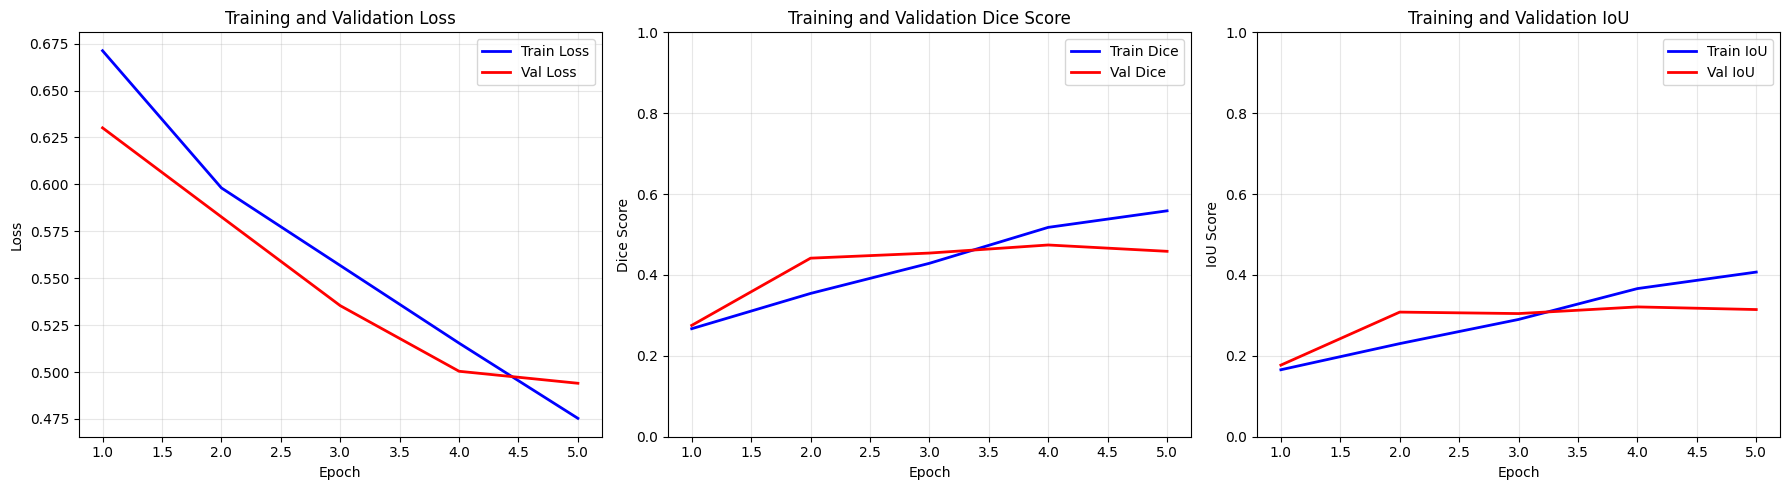

 Training history saved as 'training_history.png'


In [6]:
# ============================================
# PLOT TRAINING HISTORY
# ============================================

import matplotlib.pyplot as plt
import numpy as np

def plot_training_history(history):
    """
    Plot training and validation metrics
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss plot
    axes[0].plot(epochs, history['train_loss'], 'b-', linewidth=2, label='Train Loss')
    axes[0].plot(epochs, history['val_loss'], 'r-', linewidth=2, label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Dice plot
    axes[1].plot(epochs, history['train_dice'], 'b-', linewidth=2, label='Train Dice')
    axes[1].plot(epochs, history['val_dice'], 'r-', linewidth=2, label='Val Dice')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Dice Score')
    axes[1].set_title('Training and Validation Dice Score')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim([0, 1])
    
    # IoU plot
    axes[2].plot(epochs, history['train_iou'], 'b-', linewidth=2, label='Train IoU')
    axes[2].plot(epochs, history['val_iou'], 'r-', linewidth=2, label='Val IoU')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('IoU Score')
    axes[2].set_title('Training and Validation IoU')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    axes[2].set_ylim([0, 1])
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(" Training history saved as 'training_history.png'")

# Plot the history from training
plot_training_history(history)

 Loaded best model from epoch 4
   Validation Dice: 0.4741


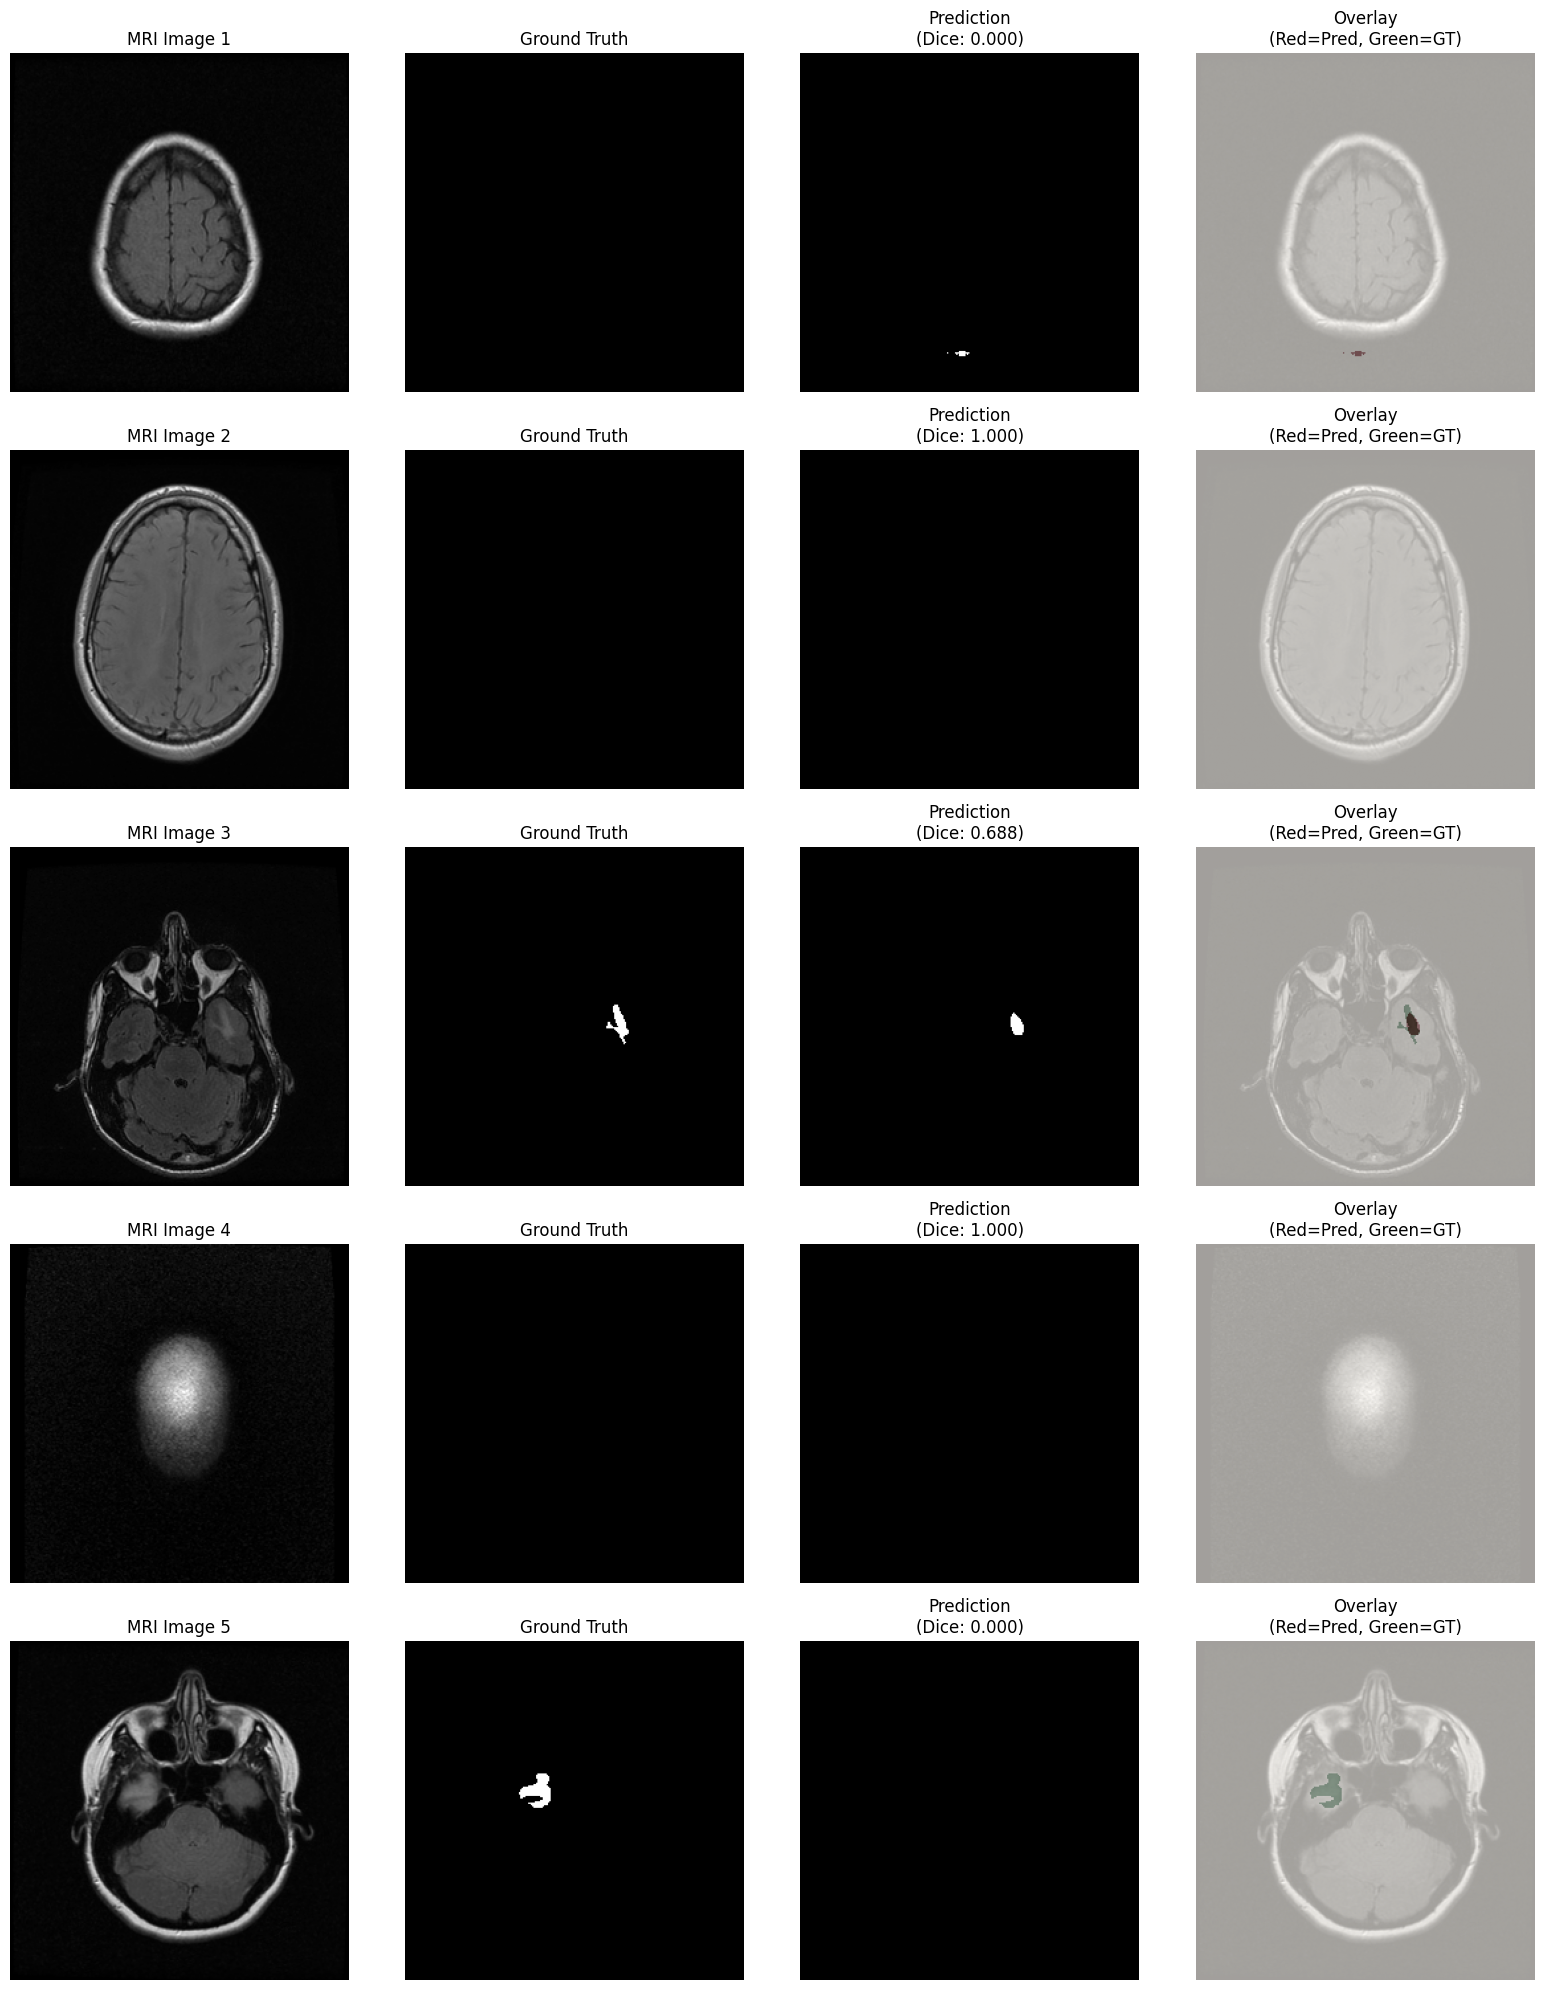

 Predictions saved as 'predictions.png'


In [7]:
# ============================================
# LOAD BEST MODEL & VISUALIZE PREDICTIONS
# ============================================

import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm

# Load the best model
checkpoint = torch.load('best_model.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f" Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"   Validation Dice: {checkpoint['val_dice']:.4f}")

# ============================================
# VISUALIZE PREDICTIONS
# ============================================

def visualize_predictions(model, dataloader, device, num_samples=5):
    """
    Visualize model predictions vs ground truth
    Shows: Original MRI | Ground Truth | Prediction | Overlay
    """
    model.eval()
    
    # Get a batch
    images, masks = next(iter(dataloader))
    images = images.to(device)
    
    # Get predictions
    with torch.no_grad():
        predictions = model(images)
    
    # Move to CPU
    images = images.cpu()
    predictions = predictions.cpu()
    
    # Limit samples
    num_samples = min(num_samples, images.size(0))
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))
    
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(num_samples):
        img = images[i, 0].numpy()
        mask = masks[i, 0].numpy()
        pred = predictions[i, 0].numpy()
        pred_binary = (pred > 0.5).astype(np.float32)
        
        # Calculate Dice for this sample
        intersection = (pred_binary * mask).sum()
        union = pred_binary.sum() + mask.sum()
        dice = (2. * intersection + 1e-6) / (union + 1e-6)
        
        # Original Image
        axes[i, 0].imshow(img, cmap='gray')
        axes[i, 0].set_title(f'MRI Image {i+1}', fontsize=12)
        axes[i, 0].axis('off')
        
        # Ground Truth
        axes[i, 1].imshow(mask, cmap='gray', vmin=0, vmax=1)
        axes[i, 1].set_title('Ground Truth', fontsize=12)
        axes[i, 1].axis('off')
        
        # Prediction
        axes[i, 2].imshow(pred_binary, cmap='gray', vmin=0, vmax=1)
        axes[i, 2].set_title(f'Prediction\n(Dice: {dice:.3f})', fontsize=12)
        axes[i, 2].axis('off')
        
        # Overlay
        axes[i, 3].imshow(img, cmap='gray')
        axes[i, 3].imshow(pred_binary, cmap='Reds', alpha=0.5)
        axes[i, 3].imshow(mask, cmap='Greens', alpha=0.3)
        axes[i, 3].set_title('Overlay\n(Red=Pred, Green=GT)', fontsize=12)
        axes[i, 3].axis('off')
    
    plt.tight_layout()
    plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(" Predictions saved as 'predictions.png'")

# Show predictions
visualize_predictions(model, val_loader, device, num_samples=5)

Scanning all validation samples for tumors...


Processing: 100%|██████████| 50/50 [00:12<00:00,  3.99it/s]



 Found 265 samples with tumors
   Worst Dice range: 0.0000 - 0.0000
   Best Dice range:  0.8677 - 0.9133


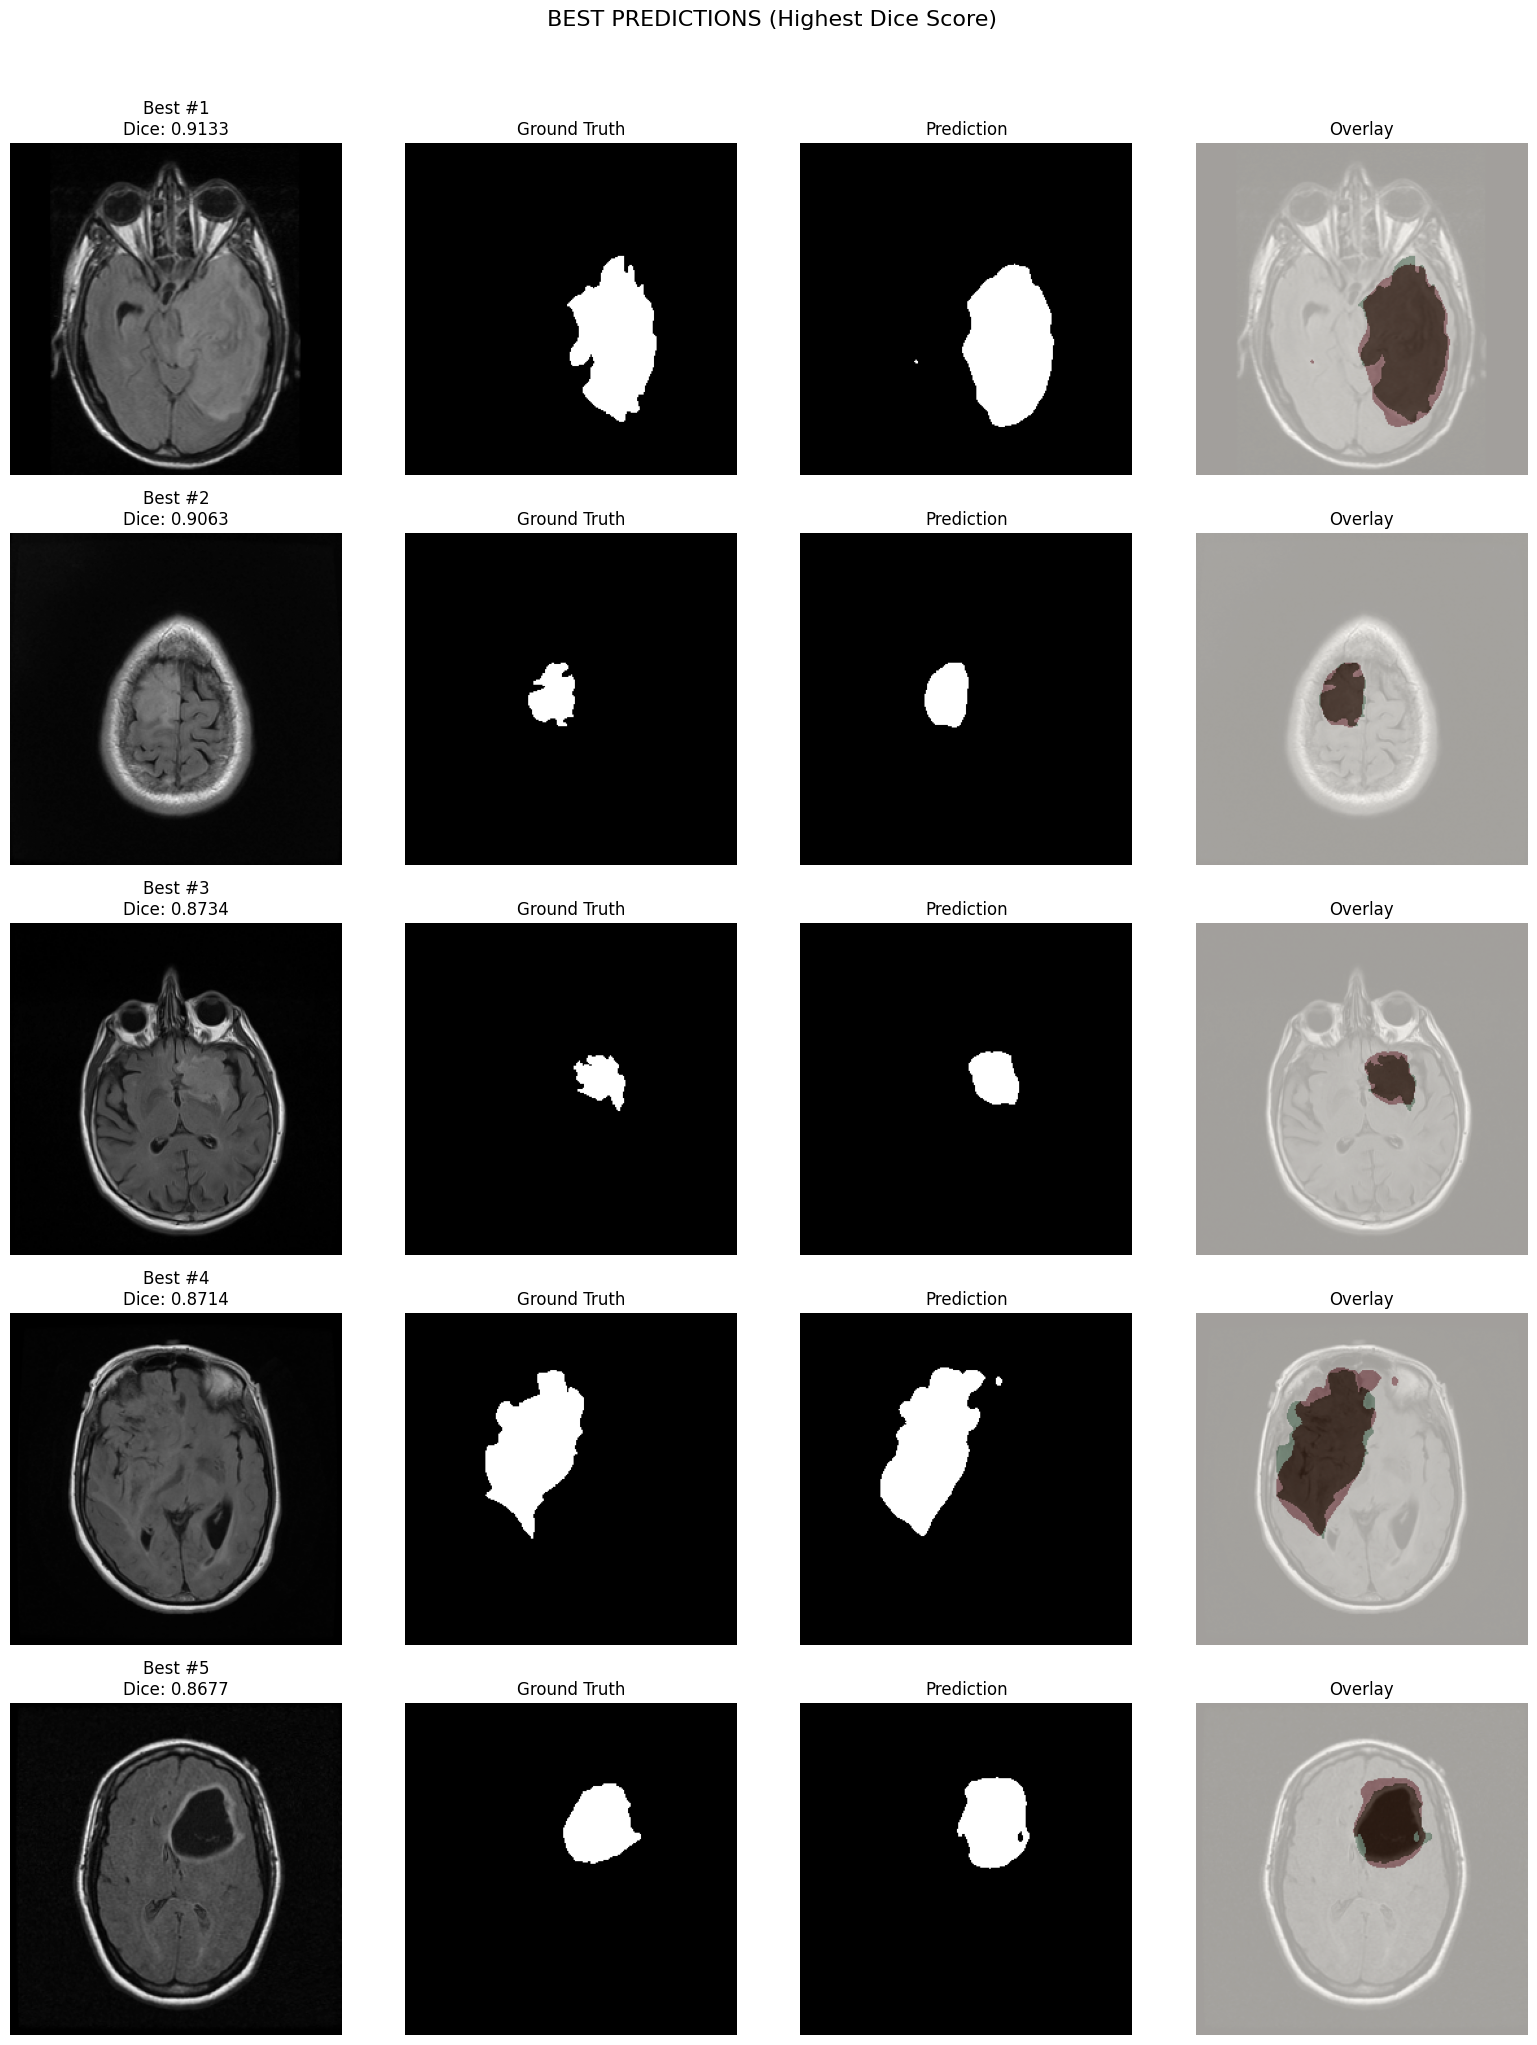

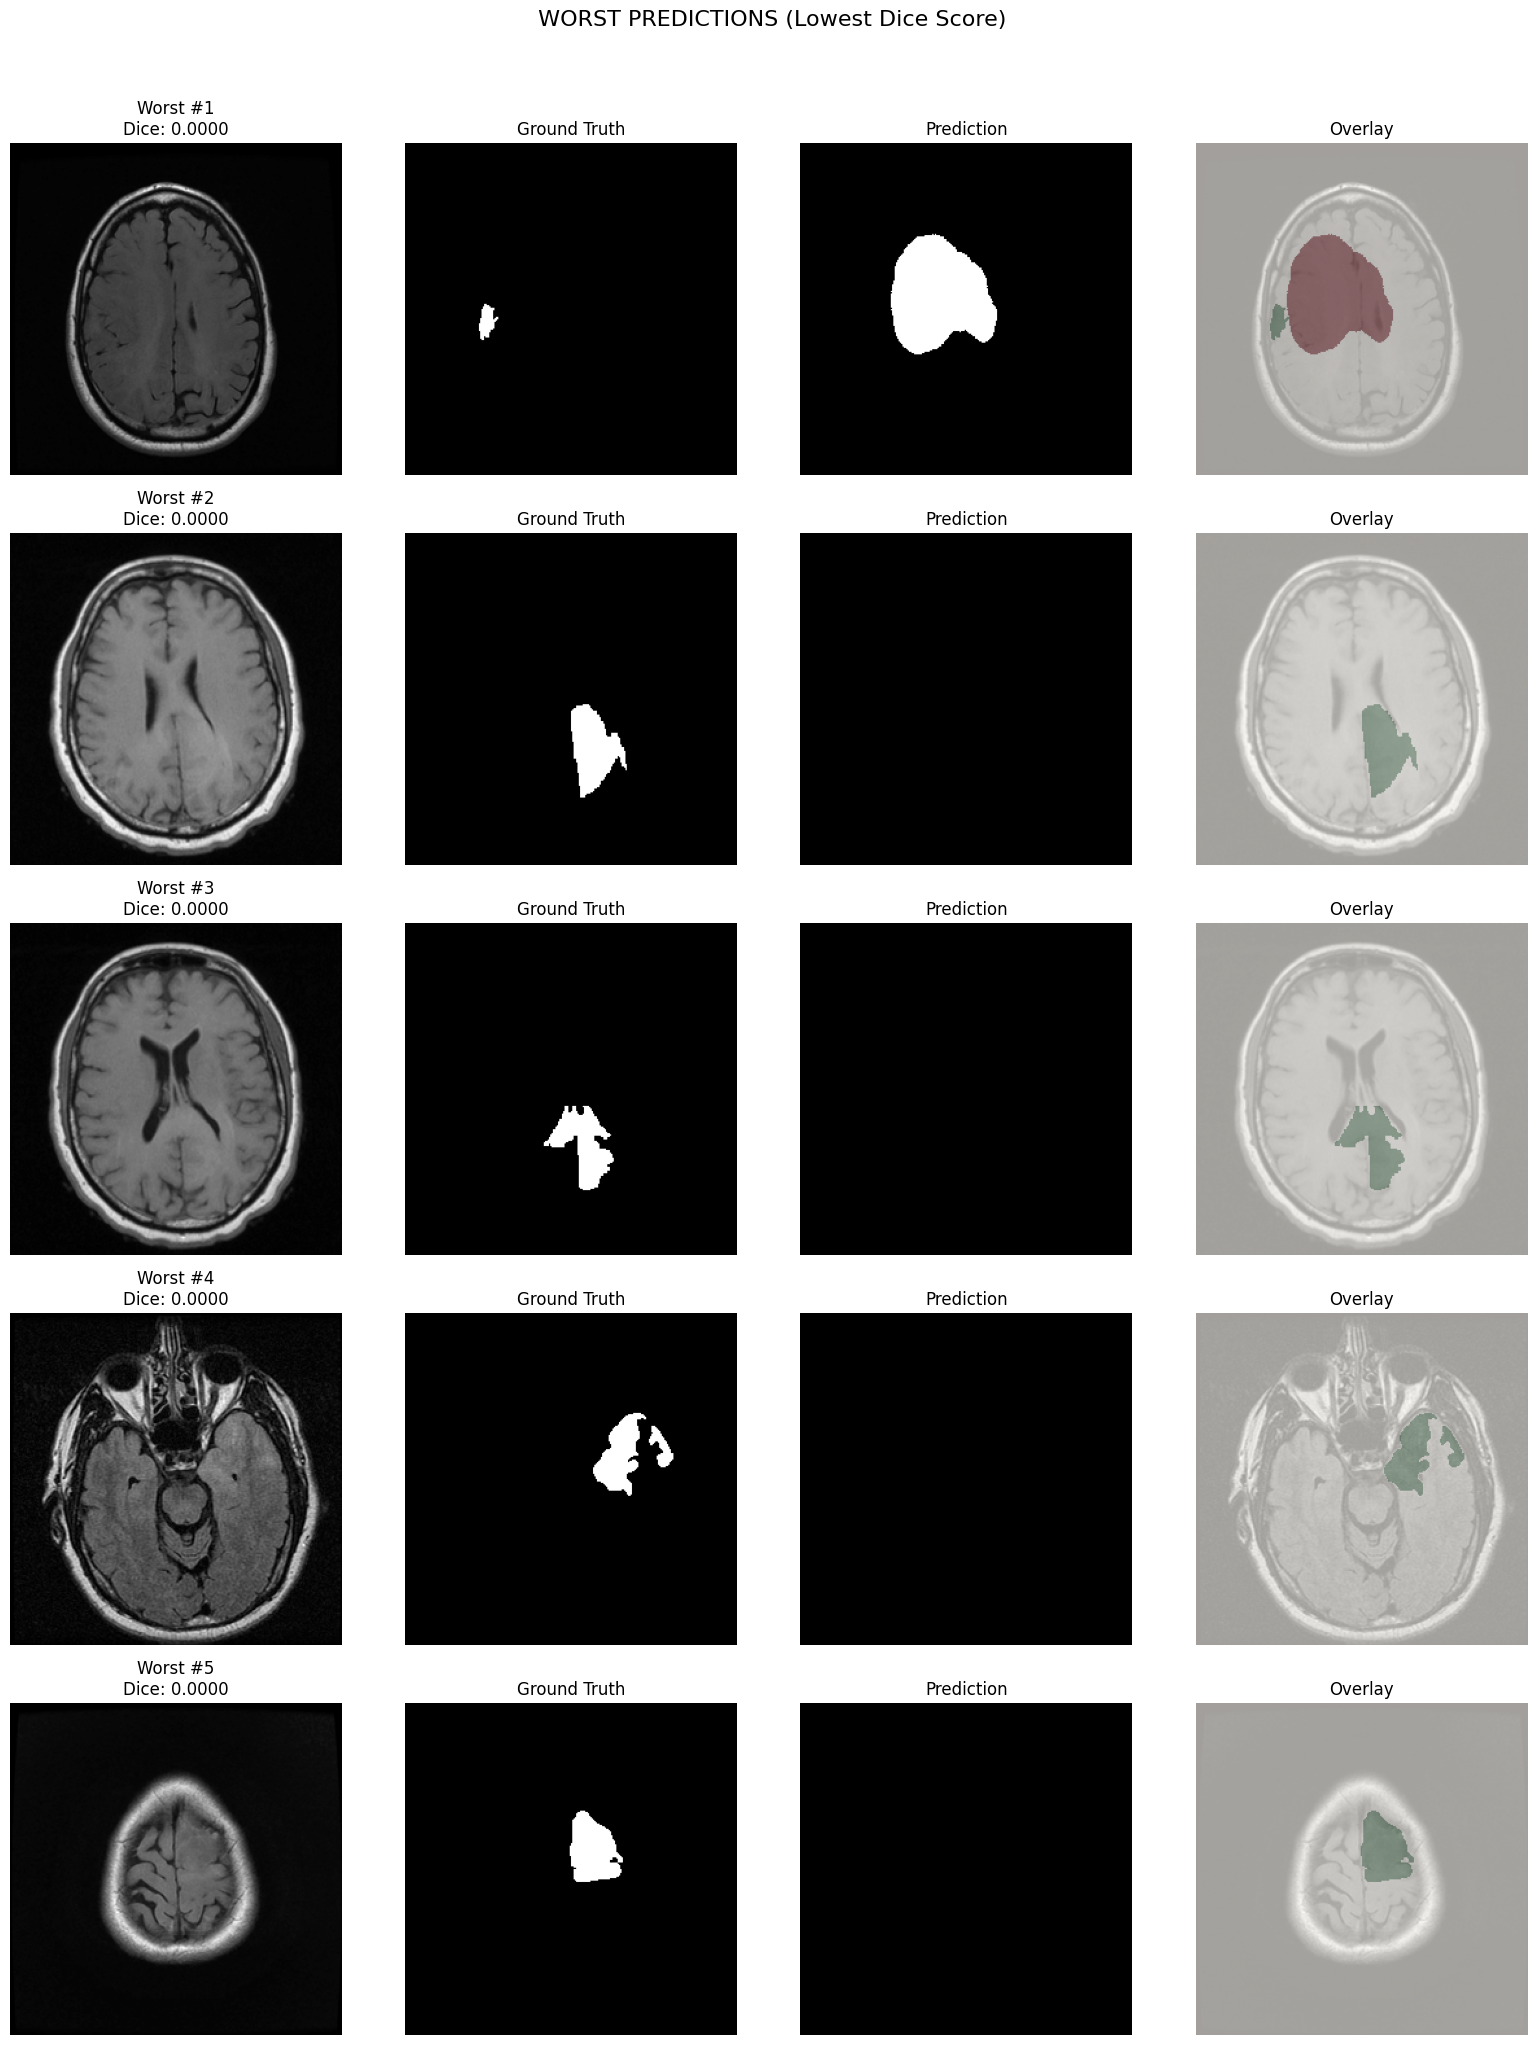

 Best predictions saved as 'best_predictions.png'
 Worst predictions saved as 'worst_predictions.png'


In [8]:
# ============================================
# FIND BEST & WORST PREDICTIONS
# ============================================

def find_extreme_predictions(model, dataloader, device, num_samples=5):
    """
    Find the best and worst predictions based on Dice score
    Only considers samples that HAVE tumor in ground truth
    """
    model.eval()
    
    all_data = []  # Store (image, mask, prediction, dice)
    
    print("Scanning all validation samples for tumors...")
    
    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="Processing"):
            images_gpu = images.to(device)
            predictions = model(images_gpu).cpu()
            
            for i in range(images.size(0)):
                img = images[i, 0]
                mask = masks[i, 0]
                pred = (predictions[i, 0] > 0.5).float()
                
                # Only consider samples WITH tumor
                if mask.sum() > 100:  # At least 100 tumor pixels
                    intersection = (pred * mask).sum()
                    union = pred.sum() + mask.sum()
                    dice = (2. * intersection + 1e-6) / (union + 1e-6)
                    
                    all_data.append({
                        'image': img,
                        'mask': mask,
                        'pred': pred,
                        'dice': dice.item()
                    })
    
    # Sort by Dice score
    all_data.sort(key=lambda x: x['dice'])
    
    worst = all_data[:num_samples]   # Lowest Dice
    best = all_data[-num_samples:]   # Highest Dice
    best = best[::-1]                # Reverse so highest is first
    
    print(f"\n Found {len(all_data)} samples with tumors")
    print(f"   Worst Dice range: {worst[-1]['dice']:.4f} - {worst[0]['dice']:.4f}")
    print(f"   Best Dice range:  {best[-1]['dice']:.4f} - {best[0]['dice']:.4f}")
    
    # ============ PLOT BEST PREDICTIONS ============
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i, data in enumerate(best):
        axes[i, 0].imshow(data['image'], cmap='gray')
        axes[i, 0].set_title(f'Best #{i+1}\nDice: {data["dice"]:.4f}')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(data['mask'], cmap='gray', vmin=0, vmax=1)
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(data['pred'], cmap='gray', vmin=0, vmax=1)
        axes[i, 2].set_title('Prediction')
        axes[i, 2].axis('off')
        
        axes[i, 3].imshow(data['image'], cmap='gray')
        axes[i, 3].imshow(data['pred'], cmap='Reds', alpha=0.5)
        axes[i, 3].imshow(data['mask'], cmap='Greens', alpha=0.3)
        axes[i, 3].set_title('Overlay')
        axes[i, 3].axis('off')
    
    plt.suptitle(' BEST PREDICTIONS (Highest Dice Score)', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig('best_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # ============ PLOT WORST PREDICTIONS ============
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i, data in enumerate(worst):
        axes[i, 0].imshow(data['image'], cmap='gray')
        axes[i, 0].set_title(f'Worst #{i+1}\nDice: {data["dice"]:.4f}')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(data['mask'], cmap='gray', vmin=0, vmax=1)
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(data['pred'], cmap='gray', vmin=0, vmax=1)
        axes[i, 2].set_title('Prediction')
        axes[i, 2].axis('off')
        
        axes[i, 3].imshow(data['image'], cmap='gray')
        axes[i, 3].imshow(data['pred'], cmap='Reds', alpha=0.5)
        axes[i, 3].imshow(data['mask'], cmap='Greens', alpha=0.3)
        axes[i, 3].set_title('Overlay')
        axes[i, 3].axis('off')
    
    plt.suptitle(' WORST PREDICTIONS (Lowest Dice Score)', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig('worst_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(" Best predictions saved as 'best_predictions.png'")
    print(" Worst predictions saved as 'worst_predictions.png'")
    
    return best, worst

# Find extreme predictions
best_preds, worst_preds = find_extreme_predictions(model, val_loader, device, num_samples=5)

In [9]:
# ============================================
# FINAL SUMMARY
# ============================================

print("="*70)
print(" DAY 2 TRAINING COMPLETE - SUMMARY")
print("="*70)

print(f"\n Model Performance:")
print(f"   Best Validation Dice: {checkpoint['val_dice']:.4f}")
print(f"   Best Epoch: {checkpoint['epoch']+1}")
print(f"   Total Parameters: {sum(p.numel() for p in model.parameters()):,}")

print(f"\n Training Progress:")
for i in range(len(history['train_loss'])):
    print(f"   Epoch {i+1}: Train Dice={history['train_dice'][i]:.4f}, Val Dice={history['val_dice'][i]:.4f}")

print(f"\n Saved Files:")
print(f"   - best_model.pth (trained model weights)")
print(f"   - training_history.png (loss/dice curves)")
print(f"   - predictions.png (sample predictions)")
print(f"   - best_predictions.png (best cases)")
print(f"   - worst_predictions.png (worst cases)")

print(f"\n Next Steps for Day 3:")
print(f"   1. Train for more epochs (30-50) for better results")
print(f"   2. Try different loss functions")
print(f"   3. Experiment with learning rate")
print(f"   4. Add more data augmentation")

print("\n" + "="*70)

 DAY 2 TRAINING COMPLETE - SUMMARY

 Model Performance:
   Best Validation Dice: 0.4741
   Best Epoch: 4
   Total Parameters: 31,036,481

 Training Progress:
   Epoch 1: Train Dice=0.2671, Val Dice=0.2753
   Epoch 2: Train Dice=0.3543, Val Dice=0.4415
   Epoch 3: Train Dice=0.4288, Val Dice=0.4542
   Epoch 4: Train Dice=0.5177, Val Dice=0.4741
   Epoch 5: Train Dice=0.5586, Val Dice=0.4585

 Saved Files:
   - best_model.pth (trained model weights)
   - training_history.png (loss/dice curves)
   - predictions.png (sample predictions)
   - best_predictions.png (best cases)
   - worst_predictions.png (worst cases)

 Next Steps for Day 3:
   1. Train for more epochs (30-50) for better results
   2. Try different loss functions
   3. Experiment with learning rate
   4. Add more data augmentation

